In [28]:
!pip install hmmlearn

## Market and Fundamental Data Ingestion

In [29]:
import pandas as pd
import numpy as np
from hmmlearn import hmm
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import matplotlib.ticker as mtick
import warnings
import os
from scipy.stats import norm, ttest_1samp

warnings.filterwarnings('ignore')

# Define Train / Test window
train_start, train_end = '2007-01-01', '2017-12-31'

test_start = '2018-01-01'
test_end = '2024-12-31'

holdout_start = '2025-01-01'
holdout_end = '2026-03-31'

# Market Data
tickers = ['NVDA', 'INTC', 'QCOM', 'AMD', 'MSFT', 'ADBE', 'INTU', 'AAPL', 'CSCO', 'AMAT']

if not os.path.exists("market_data_2007_2026.csv"):
    raise FileNotFoundError("'market_data_2007_2026.csv' not found. Please ensure the file is in the same directory.")

raw_market_data = pd.read_csv("market_data_2007_2026.csv", index_col=0, parse_dates=True)

data = raw_market_data.loc[train_start:holdout_end]
prices = data[tickers].ffill()
xlk, vix = data['XLK'], data['^VIX']

log_returns = np.log(prices / prices.shift(1)).dropna()
xlk_returns = np.log(xlk / xlk.shift(1)).dropna()

# Fundamental Alignment (POINT-IN-TIME)
raw_fund_csv = pd.read_csv('Thesis_Fundamentals.csv', parse_dates=['Date'])
real_fund_data = pd.DataFrame(index=log_returns.index)

for ticker in tickers:
    ticker_fs = raw_fund_csv[raw_fund_csv['Ticker'] == ticker].sort_values('Date').copy()
    ticker_fs['Available_Date'] = ticker_fs['Date'] + pd.Timedelta(days=60)

    market_dates = pd.DataFrame({'Market_Date': log_returns.index})

    aligned = pd.merge_asof(
        market_dates,
        ticker_fs.sort_values('Available_Date'),
        left_on='Market_Date',
        right_on='Available_Date',
        direction='backward').set_index('Market_Date')

    real_fund_data[f'{ticker}_ROE'] = aligned['Net_Income'] / aligned['Total_Equity']
    real_fund_data[f'{ticker}_FCF_Margin'] = (aligned['Operating_CF'] + aligned['CapEx']) / aligned['Revenue']

real_fund_data.to_csv("aligned_fundamentals_debug.csv")

print("Saved: aligned_fundamentals_debug.csv")
print(real_fund_data.shape)

Saved: aligned_fundamentals_debug.csv
(4839, 20)


The reporting dates assigned to fundamental observations in FastFS were manually cross-checked against historical earnings release dates for representative firms including Apple, Cisco, and NVIDIA. The database was found to index observations by fiscal quarter-end rather than public disclosure date, which would introduce look-ahead bias if used directly.

Observed reporting delays typically ranged between 42 and 60 calendar days. To conservatively approximate information availability, each fundamental observation was shifted forward by 60 calendar days prior to alignment with daily market data.

For example, if a quarterly observation was timestamped January 1 but publicly released on February 28, the model only incorporated the information after the imposed lag window.


# **1. Training & Alpha Engine**

## HMM Training and Application (Regime Detection Model)

In [30]:
print(f"Training HMM ({train_start} to {train_end})")
xlk_vol_20 = xlk_returns.rolling(window=20).std() * np.sqrt(252)
hmm_raw = pd.DataFrame({'Ret': xlk_returns, 'VIX': vix, 'Vol': xlk_vol_20}).dropna()

train_data = hmm_raw.loc[train_start:train_end]
train_mean, train_std = train_data.mean(), train_data.std()
train_scaled = (train_data - train_mean) / train_std

model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=2000, random_state=42)
model.fit(train_scaled)

train_states = model.predict(train_scaled)
high_risk_state = np.argmax([train_data[train_states == i]['VIX'].mean() for i in range(2)])

# Application (2018-2026)
print(f"Applying to Out-of-Sample ({test_start} to {holdout_end})")

test_data = hmm_raw.loc[test_start:holdout_end]
test_scaled = (test_data - train_mean) / train_std
test_probs = model.predict_proba(test_scaled)

prob_high_risk_oos = pd.Series(
    test_probs[:, high_risk_state],
    index=test_data.index)

Training HMM (2007-01-01 to 2017-12-31)
Applying to Out-of-Sample (2018-01-01 to 2026-03-31)


A two-state Gaussian Hidden Markov Model is estimated on the 2007–2017 training sample using sector returns, implied volatility (VIX), and realized XLK volatility.

The latent state exhibiting the higher average VIX level is classified as the high-risk regime. The fitted model is then applied without re-estimation to the 2018–2026 out-of-sample period, generating a daily posterior probability of market stress used for portfolio exposure scaling.

## Quality Signal Construction

In [31]:
def quarterly_zscore(series, window=4):
    q = series[series.ne(series.shift())].dropna(); mean = q.rolling(window).mean(); std = q.rolling(window).std().replace(0, np.nan)
    z = ((q - mean) / std).clip(-3, 3)
    return z.reindex(series.index).ffill()


def rolling_zscore_winsorized(series, window=60):
    mean = series.rolling(window).mean(); std = series.rolling(window).std().replace(0, np.nan)
    z = ((series - mean) / std).clip(-3, 3)
    return z

oos_prices = prices.loc[test_start:]
price_returns = oos_prices.pct_change().dropna()

oos_index = price_returns.index

raw_scores = pd.DataFrame(index=oos_index, columns=tickers)

for ticker in tickers:
    qual = (quarterly_zscore(real_fund_data[f'{ticker}_ROE']) + quarterly_zscore(real_fund_data[f'{ticker}_FCF_Margin'])).loc[test_start:].ffill().fillna(0)
    qual = qual / qual.std()
    score = qual

    raw_scores[ticker] = score

- Standardizes ROE and FCF Margin using rolling 4-quarter z-scores
- Combines both FCF Margin and ROE metrics into a composite quality factor
- Normalizes scores across stocks

The final adjusted scores are used for weekly portfolio ranking and allocation.

## Portfolio Construction & Allocation

In [32]:
rankings = raw_scores.rank(axis=1, pct=True)

# Top 30% Equal Weight
top_mask = (rankings > 0.70)
normalized_weights = top_mask.div(top_mask.sum(axis=1), axis=0).fillna(0)

# (Circuit Breaker)
risk_multiplier = pd.Series(
    np.where(prob_high_risk_oos > 0.9, np.clip(1 - prob_high_risk_oos, 0.3, 1.0), 1.0),
    index=prob_high_risk_oos.index
)
target_alloc_daily = normalized_weights.multiply(risk_multiplier, axis=0)

target_alloc = target_alloc_daily.resample('W-FRI').last().reindex(target_alloc_daily.index).ffill()
raw_target_alloc = normalized_weights.resample('W-FRI').last().reindex(normalized_weights.index).ffill()
bottom_weights_daily = (rankings <= 0.30).div((rankings <= 0.30).sum(axis=1), axis=0).fillna(0)
bottom_weights = bottom_weights_daily.resample('W-FRI').last().reindex(bottom_weights_daily.index).ffill()

# Represents buying all 10 stocks equally (10% each) and holding them.
univ_ew_weights = pd.DataFrame(1/len(tickers), index=oos_index, columns=tickers)
univ_ew_weights = univ_ew_weights.resample('W-FRI').last().reindex(univ_ew_weights.index).ffill()


- Selects the top 30% of ranked stocks
- Applies equal-weight allocation across selected positions
- Reduces portfolio exposure when high-risk regime probability exceeds 90%, with a minimum 30% invested allocation
- Rebalances weekly to refresh portfolio weights
- Builds benchmark comparison portfolios

## Weekly Rebalancing & Transaction Costs

In [33]:
tc_bps = 0.0005

strat_ret_gross = (target_alloc.shift(1) * price_returns).sum(axis=1)
raw_strat_ret_gross = (raw_target_alloc.shift(1) * price_returns).sum(axis=1)
bottom_ret_gross = (bottom_weights.shift(1) * price_returns).sum(axis=1)
univ_ew_ret_gross = (univ_ew_weights.shift(1) * price_returns).sum(axis=1)

turnover = target_alloc.diff().abs().sum(axis=1).fillna(0)
raw_turnover = raw_target_alloc.diff().abs().sum(axis=1).fillna(0)
bottom_turnover = bottom_weights.diff().abs().sum(axis=1).fillna(0)
univ_ew_turnover = univ_ew_weights.diff().abs().sum(axis=1).fillna(0)

strat_ret_net = strat_ret_gross - (turnover * tc_bps)
raw_strat_ret_net = raw_strat_ret_gross - (raw_turnover * tc_bps)
bottom_ret_net = bottom_ret_gross - (bottom_turnover * tc_bps)
univ_ew_ret_net = univ_ew_ret_gross - (univ_ew_turnover * tc_bps)

eval_res = pd.DataFrame({
    'HMM Top 30% Strategy': strat_ret_net,
    'Raw Top 30% Strategy': raw_strat_ret_net,
    'Bottom 30% Strategy': bottom_ret_net,
    'Universe EW (No Alpha)': univ_ew_ret_net,
    'XLK Benchmark': xlk.loc[test_start:].pct_change()
}).dropna()

validation_res = eval_res.loc[test_start:test_end]
holdout_res = eval_res.loc[holdout_start:holdout_end]

Realistic implementation assumptions:

- Rebalances weekly to reduce excessive turnover
- Applies transaction costs of 5 bps trade
- Computes net returns after turnover costs
- Separates validation and final holdout evaluation periods


# **2. Validation Results**

This section evaluates out-of-sample performance over 2018–2024.

It begins with a point-in-time portfolio construction audit, followed by performance diagnostics, factor validation, and cumulative return analysis.

## Monthly Portfolio Holdings (2024)

In [34]:
holdings_2024 = target_alloc.loc['2024'].resample('M').last()

monthly_comp = []

for date, row in holdings_2024.iterrows():
    active = row[row > 0].sort_values(ascending=False)

    month_data = {'Month': date.strftime('%b')}

    for i, (stock, weight) in enumerate(active.items(), 1):
        month_data[f'Holding {i}'] = f'{stock} ({weight:.0%})'

    monthly_comp.append(month_data)

monthly_comp_df = pd.DataFrame(monthly_comp)

display(monthly_comp_df)

,Month,Holding 1,Holding 2,Holding 3
0,Jan,NVDA (33%),INTC (33%),MSFT (33%)
1,Feb,INTC (33%),QCOM (33%),AAPL (33%)
2,Mar,NVDA (33%),QCOM (33%),AAPL (33%)
3,Apr,NVDA (33%),QCOM (33%),AAPL (33%)
4,May,NVDA (33%),AMD (33%),INTU (33%)
5,Jun,NVDA (33%),AMD (33%),INTU (33%)
6,Jul,NVDA (10%),ADBE (10%),INTU (10%)
7,Aug,AMD (10%),ADBE (10%),AAPL (10%)
8,Sep,AMD (10%),ADBE (10%),AAPL (10%)
9,Oct,AMD (33%),ADBE (33%),AAPL (33%)


- Healthy Snapshot Check: **33% weights** reflect full allocation during low-risk regimes, while **10% weights** indicate defensive scaling during elevated market-risk periods.

## Validation Signal Dashboard (2024-12-27)

(Shows the quarterly fundamental inputs used in scoring)

In [35]:
inspect_date = pd.Timestamp('2024-12-27')

audit_rows = []; history_rows = []

for ticker in tickers:

    roe_series = real_fund_data[f'{ticker}_ROE']; fcf_series = real_fund_data[f'{ticker}_FCF_Margin']

    roe_q = roe_series[roe_series.ne(roe_series.shift())].dropna()
    fcf_q = fcf_series[fcf_series.ne(fcf_series.shift())].dropna()

    roe_z_full = quarterly_zscore(roe_series)
    fcf_z_full = quarterly_zscore(fcf_series)

    roe_z = roe_z_full.loc[test_start:].ffill().fillna(0)
    fcf_z = fcf_z_full.loc[test_start:].ffill().fillna(0)

    qual = roe_z + fcf_z; qual = qual / qual.std()

    audit_rows.append({
        'Ticker': ticker,
        'ROE Z': roe_z.loc[inspect_date], 'FCF Z': fcf_z.loc[inspect_date],
        'Raw Quality': roe_z.loc[inspect_date] + fcf_z.loc[inspect_date],
        'Quality Score': qual.loc[inspect_date]})

    roe_hist = roe_q.loc[:inspect_date].tail(4)
    fcf_hist = fcf_q.loc[:inspect_date].tail(4)

    history_rows.append({
        'Ticker': ticker,

        'ROE Q-3': roe_hist.iloc[-4] if len(roe_hist)>=4 else np.nan,
        'ROE Q-2': roe_hist.iloc[-3] if len(roe_hist)>=3 else np.nan,
        'ROE Q-1': roe_hist.iloc[-2] if len(roe_hist)>=2 else np.nan,
        'ROE Current': roe_hist.iloc[-1] if len(roe_hist)>=1 else np.nan,

        'FCF Q-3': fcf_hist.iloc[-4] if len(fcf_hist)>=4 else np.nan,
        'FCF Q-2': fcf_hist.iloc[-3] if len(fcf_hist)>=3 else np.nan,
        'FCF Q-1': fcf_hist.iloc[-2] if len(fcf_hist)>=2 else np.nan,
        'FCF Current': fcf_hist.iloc[-1] if len(fcf_hist)>=1 else np.nan})

audit_df = pd.DataFrame(audit_rows)
audit_df['Rank Percentile'] = audit_df['Quality Score'].rank(pct=True); audit_df['Selected'] = audit_df['Rank Percentile'] > 0.70
n_selected = audit_df['Selected'].sum()
audit_df['Base Weight'] = np.where(audit_df['Selected'], 1/n_selected, 0)
risk_prob = prob_high_risk_oos.loc[inspect_date]; risk_mult = np.clip(1-risk_prob,0.3,1.0) if risk_prob > 0.9 else 1.0
audit_df['HMM Prob'] = risk_prob; audit_df['Risk Multiplier'] = risk_mult; audit_df['Final Weight'] = audit_df['Base Weight'] * risk_mult
audit_df = audit_df.sort_values('Quality Score', ascending=False)
history_df = pd.DataFrame(history_rows)

print("\nQUALITY RANKING TABLE"); display(audit_df.round(4))

print("\nTRUE QUARTERLY OBSERVATIONS USED FOR Z-SCORE"); display(history_df.round(4))


QUALITY RANKING TABLE


,Ticker,ROE Z,FCF Z,Raw Quality,Quality Score,Rank Percentile,Selected,Base Weight,HMM Prob,Risk Multiplier,Final Weight
5,ADBE,0.8288,0.7709,1.5997,1.0848,1.0,True,0.3333,0.0068,1.0,0.3333
3,AMD,0.9899,0.5143,1.5042,1.0821,0.9,True,0.3333,0.0068,1.0,0.3333
8,CSCO,0.9871,0.3094,1.2965,1.0790,0.8,True,0.3333,0.0068,1.0,0.3333
9,AMAT,-0.5752,0.4753,-0.0999,-0.0779,0.7,False,0.0000,0.0068,1.0,0.0000
4,MSFT,-0.2081,0.0900,-0.1180,-0.0865,0.6,False,0.0000,0.0068,1.0,0.0000
0,NVDA,0.1519,-0.4465,-0.2946,-0.1805,0.5,False,0.0000,0.0068,1.0,0.0000
2,QCOM,0.5256,-1.0417,-0.5161,-0.4099,0.4,False,0.0000,0.0068,1.0,0.0000
1,INTC,-1.4715,0.5436,-0.9279,-0.6083,0.3,False,0.0000,0.0068,1.0,0.0000
6,INTU,-0.4834,-0.6433,-1.1266,-0.6773,0.2,False,0.0000,0.0068,1.0,0.0000
7,AAPL,-0.9550,-0.5673,-1.5223,-1.0346,0.1,False,0.0000,0.0068,1.0,0.0000



TRUE QUARTERLY OBSERVATIONS USED FOR Z-SCORE


,Ticker,ROE Q-3,ROE Q-2,ROE Q-1,ROE Current,FCF Q-3,FCF Q-2,FCF Q-1,FCF Current
0,NVDA,0.2858,0.3028,0.2854,0.2930,0.5088,0.5750,0.4498,0.4793
1,INTC,0.0243,-0.0034,-0.0134,-0.1587,-0.1345,-0.5653,-0.2642,-0.1810
2,QCOM,0.1200,0.0951,0.0863,0.1111,0.2753,0.3589,0.2837,0.2334
3,AMD,0.0119,0.0022,0.0047,0.0135,0.0392,0.0692,0.0752,0.0727
4,MSFT,0.0918,0.0867,0.0821,0.0857,0.1470,0.3389,0.3603,0.2936
5,ADBE,0.0898,0.0401,0.1060,0.1158,0.3071,0.2194,0.3577,0.3632
6,INTU,0.0209,0.1274,-0.0011,0.0109,0.1624,0.5774,0.1363,0.1002
7,AAPL,0.4577,0.3186,0.3215,0.2588,0.3136,0.2280,0.3114,0.2518
8,CSCO,0.0570,0.0412,0.0476,0.0599,0.0499,0.2994,0.2589,0.2488
9,AMAT,0.1158,0.0946,0.0905,0.0911,0.3125,0.1708,0.3081,0.3077


## Performance Evaluation

In [36]:
def get_stats(r):
    return [((1+r).prod()**(252/len(r)) - 1), r.std()*np.sqrt(252),
            (((1+r).prod()**(252/len(r)) - 1)/(r.std()*np.sqrt(252))),
            ((1+r).cumprod()/(1+r).cumprod().cummax() - 1).min(), (r > 0).mean()]

validation_perf = pd.DataFrame(
    {col: get_stats(validation_res[col]) for col in validation_res.columns},
    index=['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max Drawdown', 'Win Rate']).T

print("\nVALIDATION RESULTS (2018–2024)")
display(validation_perf.round(4))


VALIDATION RESULTS (2018–2024)


,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Win Rate
HMM Top 30% Strategy,0.3028,0.1850,1.6361,-0.1951,0.5494
Raw Top 30% Strategy,0.3438,0.3185,1.0792,-0.4300,0.5494
Bottom 30% Strategy,0.1282,0.3341,0.3837,-0.4901,0.5312
Universe EW (No Alpha),0.2523,0.3044,0.8288,-0.4533,0.5500
XLK Benchmark,0.2135,0.2612,0.8172,-0.3356,0.5500


- The Raw Top 30% strategy, produced a 4.10% higher absolute return than the HMM Top 30% strategy but experienced substantially elevated volatility at 31.85% and a maximum drawdown of −43.01% which is 2x of the regime aware strategy.
- The XLK sector ETF benchmark provided 21.35% annualized return with 26.12% volatility, a Sharpe ratio of 0.8172, and a maximum drawdown of −33.56%.

### Spread & Alpha Validation

In [37]:
print("\nVALIDATION SPREADS & STATISTICAL METRICS (2018–2024)")

daily_spread = validation_res['HMM Top 30% Strategy'] - validation_res['Bottom 30% Strategy']

print(f"Top-Bottom Spread Multiple: {((1+validation_res['HMM Top 30% Strategy']).prod()/(1+validation_res['Bottom 30% Strategy']).prod()):.4f}")
print(f"Spread Sharpe Ratio: {(daily_spread.mean()/daily_spread.std()*np.sqrt(252)):.4f}")
print(f"Adj Strategy Hit Rate (vs XLK): {(validation_res['HMM Top 30% Strategy']>validation_res['XLK Benchmark']).mean():.2%}")



VALIDATION SPREADS & STATISTICAL METRICS (2018–2024)
Top-Bottom Spread Multiple: 2.7312
Spread Sharpe Ratio: 0.3893
Adj Strategy Hit Rate (vs XLK): 52.16%


- Top–Bottom Spread: 2.73x cumulative separation confirms effective quality ranking.

- Spread Sharpe: 0.39 indicates moderate stability of factor performance.

- Hit Rate vs XLK: 52.16% supports persistent benchmark outperformance.

## Cumulative Returns

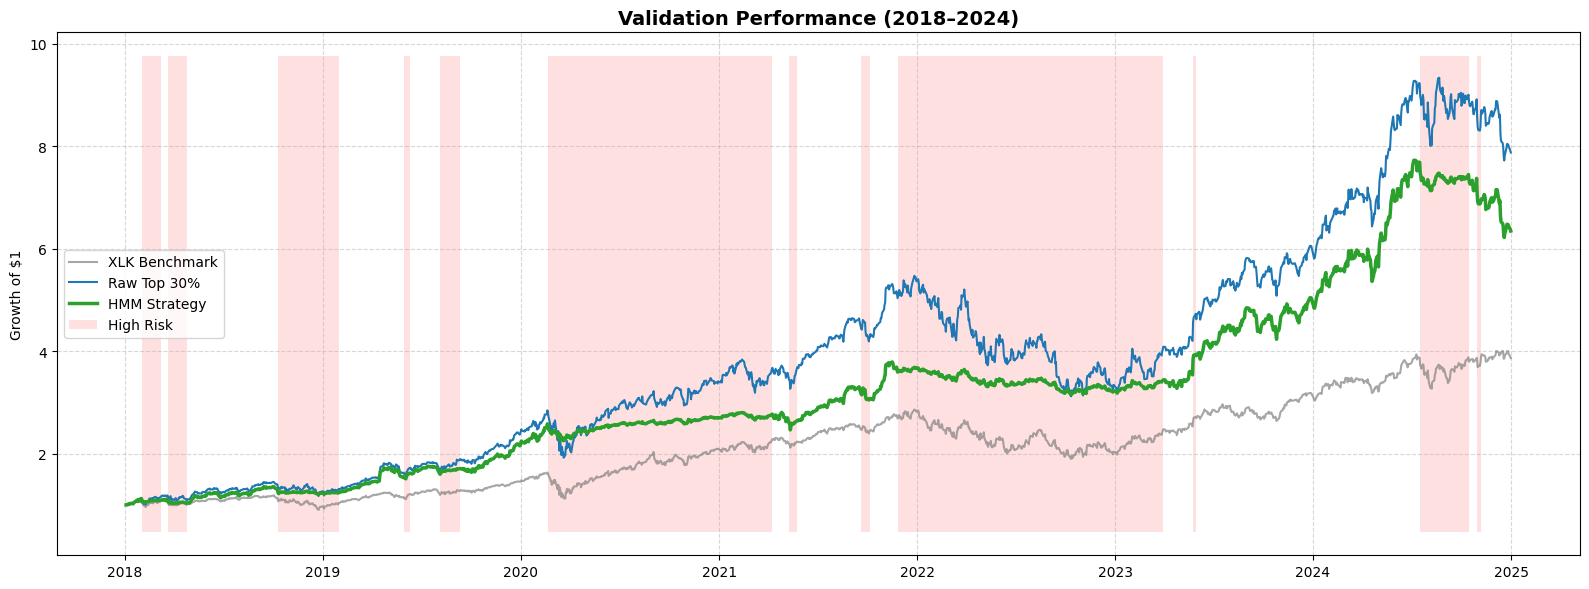

In [38]:
validation_end='2024-12-31'; holdout_start='2025-01-01'; holdout_end='2026-03-31'

# VALIDATION (2020-2024)
eval_start_date='2018-01-01'
val_strat=validation_res['HMM Top 30% Strategy'].loc[eval_start_date:validation_end]
val_raw=validation_res['Raw Top 30% Strategy'].loc[eval_start_date:validation_end]
val_bench=validation_res['XLK Benchmark'].loc[eval_start_date:validation_end]
val_regime=prob_high_risk_oos.loc[eval_start_date:validation_end]>0.5

cum_val_strat=(1+val_strat).cumprod(); cum_val_raw=(1+val_raw).cumprod(); cum_val_bench=(1+val_bench).cumprod()

fig,ax=plt.subplots(figsize=(16,6))
ax.plot(cum_val_bench.index,cum_val_bench,color='gray',label='XLK Benchmark',alpha=0.7)
ax.plot(cum_val_raw.index,cum_val_raw,color='#1f77b4',label='Raw Top 30%')
ax.plot(cum_val_strat.index,cum_val_strat,color='#2ca02c',linewidth=2.5,label='HMM Strategy')
ax.fill_between(val_regime.index,ax.get_ylim()[0],ax.get_ylim()[1],where=val_regime,facecolor='red',alpha=0.12,label='High Risk')
ax.set_title('Validation Performance (2018–2024)', fontsize=14, fontweight='bold'); ax.set_ylabel('Growth of $1'); ax.legend(); ax.grid(True,linestyle='--',alpha=0.5)
plt.tight_layout(); plt.show()

- The HMM identifies **high-risk regimes (red shaded areas)** corresponding to major market stress events:
  - **2020:** COVID-19 volatility shock  
  - **2022:** Monetary tightening and valuation compression & Russia-Ukraine War
  - **2024:** Monetary Policy Uncertainty (Higher for longer rates)

- During these periods, the **raw quality strategy experiences larger drawdowns**, while the HMM overlay scales exposure downward.

- In low-risk periods, full allocation is restored, allowing the strategy to capture quality-driven upside.

### Drawdown Chart

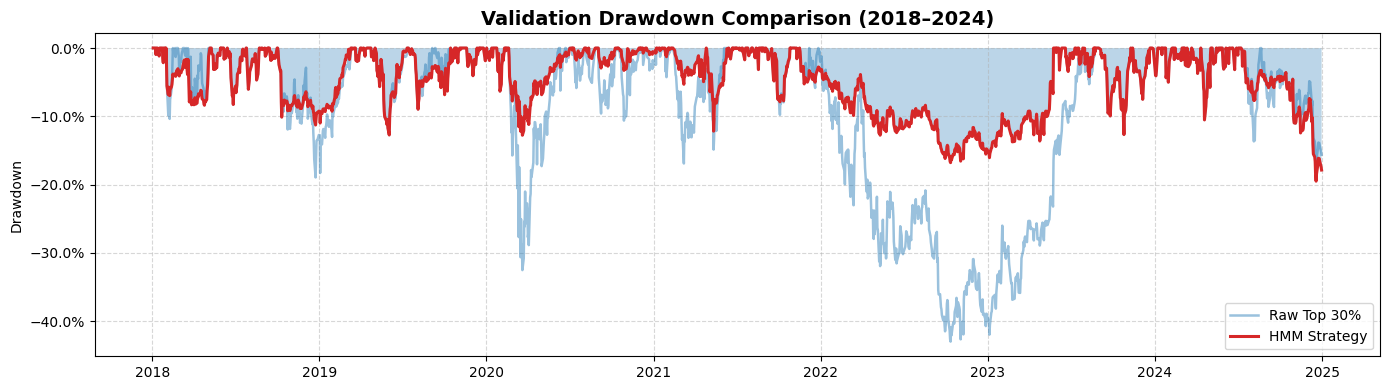

In [39]:
#(2020–2024)
fig2, ax2 = plt.subplots(figsize=(14,4))

drawdown_strat = (cum_val_strat / cum_val_strat.cummax()) - 1
drawdown_raw = (cum_val_raw / cum_val_raw.cummax()) - 1

ax2.plot(drawdown_raw.index, drawdown_raw, color='#1f77b4', alpha=0.45, linewidth=1.8, label='Raw Top 30%')
ax2.plot(drawdown_strat.index, drawdown_strat, color='#d62728', linewidth=2.2, label='HMM Strategy')
ax2.fill_between(drawdown_strat.index, drawdown_strat, 0, alpha=0.30)

ax2.set_title('Validation Drawdown Comparison (2018–2024)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Drawdown')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.legend(loc='lower right')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- The HMM strategy materially reduces drawdowns compared to the raw quality portfolio.

- Maximum drawdown improves from **-43.0% (Raw)** to **-19.5% (HMM)**.

### Monthly Heatmap & Yearly Bars

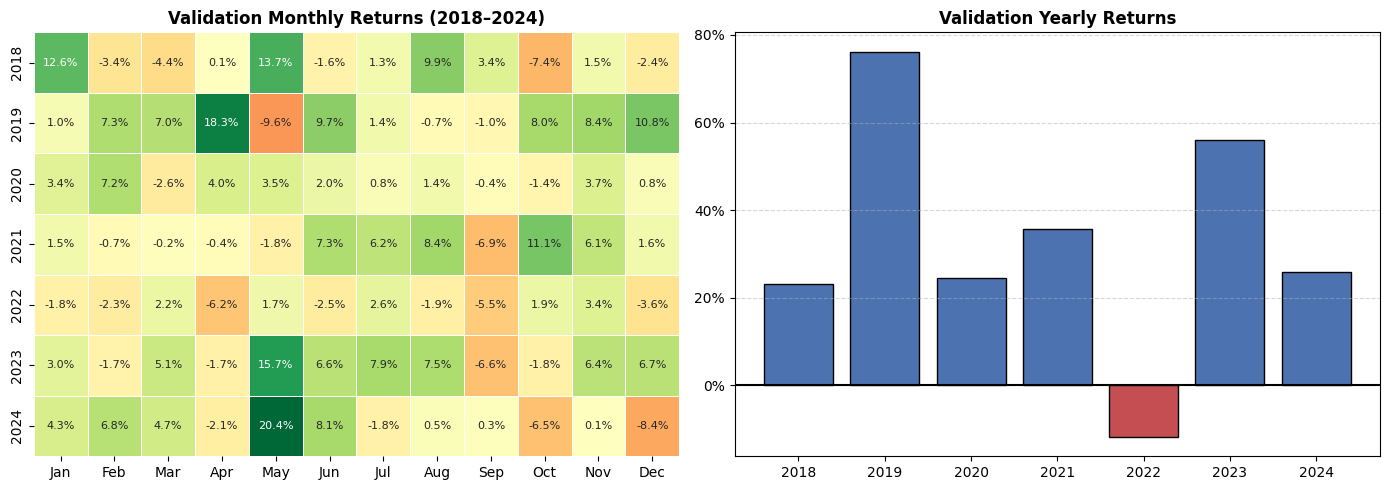

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5), gridspec_kw={'width_ratios':[1,1]})

val_monthly = validation_res['HMM Top 30% Strategy'].resample('ME').apply(lambda x:(1+x).prod()-1)
val_df = pd.DataFrame({'Return': val_monthly})
val_df['Year'] = val_df.index.year
val_df['Month'] = val_df.index.month
val_pivot = val_df.pivot(index='Year', columns='Month', values='Return')
val_pivot.columns = [calendar.month_abbr[i] for i in val_pivot.columns]

sns.heatmap(val_pivot, annot=True, fmt=".1%", cmap="RdYlGn", center=0, cbar=False,
            annot_kws={"size":8}, ax=ax1, linewidths=.5)

ax1.set_title('Validation Monthly Returns (2018–2024)', fontweight='bold')
ax1.set_ylabel('')
ax1.set_xlabel('')

val_yearly = validation_res['HMM Top 30% Strategy'].resample('YE').apply(lambda x:(1+x).prod()-1)
val_yearly.index = val_yearly.index.year
val_colors = ['#4c72b0' if v > 0 else '#c44e52' for v in val_yearly]

ax2.bar(val_yearly.index, val_yearly, color=val_colors, edgecolor='black')
ax2.axhline(0, color='black')
ax2.set_title('Validation Yearly Returns', fontweight='bold')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- Monthly returns vary accross the horizon

- Annual performance remains positive in **6 / 7 validation years**.

- The negative 2022 result reflects that the HMM-strategy is susceptible to market stress.

# **3. Robustness Testing**

## DIAGNOSTICS Regime & Score Analysis

In [41]:
print("REGIME & SCORE STATISTICS")

avg_high_risk = prob_high_risk_oos.mean()
high_risk_days = (prob_high_risk_oos > 0.5).mean()
strategy_corr = eval_res['HMM Top 30% Strategy'].corr(eval_res['XLK Benchmark'])

print(f"Average OOS high-risk probability: {avg_high_risk:.4f}")
print(f"OOS High-risk days: {high_risk_days:.2%}")
print(f"Strategy vs XLK correlation: {strategy_corr:.4f}")

REGIME & SCORE STATISTICS
Average OOS high-risk probability: 0.5189
OOS High-risk days: 51.86%
Strategy vs XLK correlation: 0.6554


- The HMM classifies **51.9%** of out-of-sample observations as elevated-risk regimes.

- The strategy has a moderate correlation with XLK (0.66), indicating it still follows the market but does not move exactly the same way.

## Ablation Study (Value Attribution)

ABLATION STUDY: CORE METRICS


,Ann. Return,Ann. Vol,Sharpe,Max Drawdown
Step 1: Universe EW (Naive Baseline),0.2523,0.3044,0.8288,-0.4533
Step 2: Factor Engine (Raw Top 30%),0.3438,0.3185,1.0792,-0.4300
Step 3: + HMM Overlay (Final Strategy),0.3028,0.1850,1.6361,-0.1951
Anti-Factor (Bottom 30%),0.1282,0.3341,0.3837,-0.4901



=== THE 'VALUE-ADD' DECONSTRUCTION ===
1. Alpha Engine Value Add (Factor vs Naive):  +0.2504 Sharpe Ratio
2. Risk Overlay Value Add (HMM vs Factor):    +0.5569 Sharpe Ratio
3. HMM Capital Protection:                    Prevented 23.50% of Absolute Max Drawdown


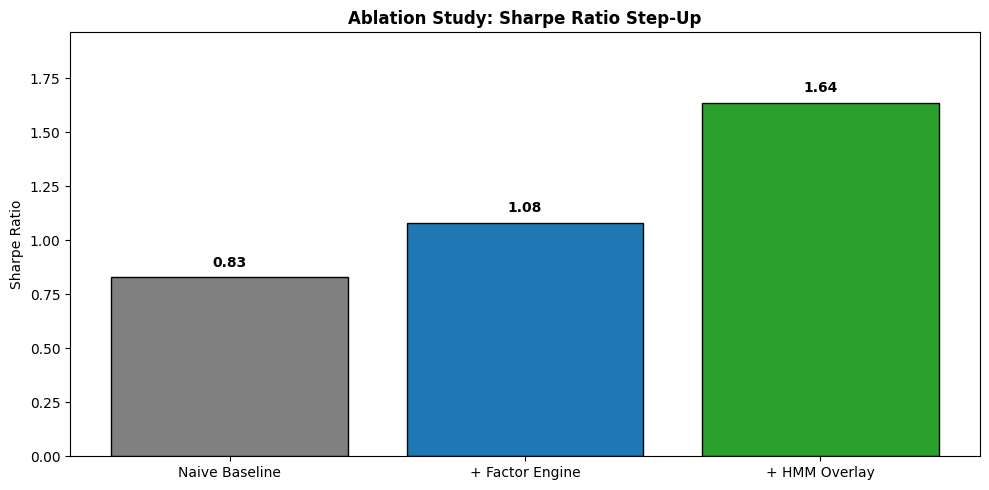

In [42]:
ablation_res = pd.DataFrame({
    'Step 1: Universe EW (Naive Baseline)': univ_ew_ret_net,
    'Step 2: Factor Engine (Raw Top 30%)': raw_strat_ret_net,
    'Step 3: + HMM Overlay (Final Strategy)': strat_ret_net,
    'Anti-Factor (Bottom 30%)': bottom_ret_net}).dropna().loc[test_start:test_end]

def get_ablation_stats(r):
    return [
        ((1+r).prod()**(252/len(r)) - 1),
        r.std()*np.sqrt(252),
        (((1+r).prod()**(252/len(r)) - 1)/(r.std()*np.sqrt(252))),
        ((1+r).cumprod()/(1+r).cumprod().cummax() - 1).min()]


ablation_table = pd.DataFrame({col: get_ablation_stats(ablation_res[col]) for col in ablation_res.columns},
                              index=['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max Drawdown']).T

print("ABLATION STUDY: CORE METRICS")
display(ablation_table.round(4))

naive_sharpe = ablation_table.loc['Step 1: Universe EW (Naive Baseline)', 'Sharpe']
factor_sharpe = ablation_table.loc['Step 2: Factor Engine (Raw Top 30%)', 'Sharpe']
hmm_sharpe = ablation_table.loc['Step 3: + HMM Overlay (Final Strategy)', 'Sharpe']

factor_dd = ablation_table.loc['Step 2: Factor Engine (Raw Top 30%)', 'Max Drawdown']
hmm_dd = ablation_table.loc['Step 3: + HMM Overlay (Final Strategy)', 'Max Drawdown']

print("\n=== THE 'VALUE-ADD' DECONSTRUCTION ===")
print(f"1. Alpha Engine Value Add (Factor vs Naive):  +{np.round(factor_sharpe - naive_sharpe, 4)} Sharpe Ratio")
print(f"2. Risk Overlay Value Add (HMM vs Factor):    +{np.round(hmm_sharpe - factor_sharpe, 4)} Sharpe Ratio")
print(f"3. HMM Capital Protection:                    Prevented {abs(factor_dd - hmm_dd):.2%} of Absolute Max Drawdown")


plt.figure(figsize=(10, 5))
sharpe_values = [naive_sharpe, factor_sharpe, hmm_sharpe]
labels = ['Naive Baseline', '+ Factor Engine', '+ HMM Overlay']
colors = ['gray', '#1f77b4', '#2ca02c']

bars = plt.bar(labels, sharpe_values, color=colors, edgecolor='black')
plt.title('Ablation Study: Sharpe Ratio Step-Up', fontweight='bold')
plt.ylabel('Sharpe Ratio')
plt.ylim(0, max(sharpe_values) * 1.2)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, round(yval, 2), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

- The **factor engine** improves Sharpe from **0.83** to **1.08**, confirming alpha generation from quality selection.

- Adding the **HMM overlay** further increases Sharpe to **1.64** while  reducing drawdown extensively compared to the rest of the benchmarks.

- Efficient cross-sectional security selection is confirmed in the weak performance of the bottom-ranked portfolio supports

## Sensitivity Analysis

The strategy was turned into a flexible function so each parameter could be changed and tested separately, making it possible to check that performance stays consistent and is not dependent on one specific setup.

In [43]:
def run_advanced_sensitivity(selection_threshold=0.70, rebalance_freq='W-FRI', hmm_threshold=0.9, tc_bps=0.0005, hmm_states=2, risk_scaling='default', vol_window=20):

    fundamentals = real_fund_data

    # HMM Inputs
    xlk_vol = xlk_returns.rolling(window=vol_window).std() * np.sqrt(252)
    hmm_raw_local = pd.DataFrame({'Ret': xlk_returns, 'VIX': vix, 'Vol': xlk_vol}).dropna()

    train_data_local = hmm_raw_local.loc[train_start:train_end]
    train_mean_local = train_data_local.mean()
    train_std_local = train_data_local.std()

    train_scaled_local = (train_data_local - train_mean_local) / train_std_local

    model_n = hmm.GaussianHMM(n_components=hmm_states, covariance_type="full", n_iter=2000, random_state=42)
    model_n.fit(train_scaled_local)

    train_states_n = model_n.predict(train_scaled_local)

    high_risk_st = np.argmax([train_data_local[train_states_n == i]['VIX'].mean() for i in range(hmm_states)])

    test_data_local = hmm_raw_local.loc[test_start:test_end]
    test_scaled_local = (test_data_local - train_mean_local) / train_std_local
    test_probs_n = model_n.predict_proba(test_scaled_local)

    local_prob_risk = pd.Series(test_probs_n[:, high_risk_st], index=test_data_local.index)

    # Returns
    local_oos_prices = prices.loc[test_start:]
    local_price_returns = local_oos_prices.pct_change().dropna()

    local_raw_scores = pd.DataFrame(index=local_price_returns.index, columns=tickers)

    # Quality Scores
    for ticker in tickers:

        qual = (quarterly_zscore(fundamentals[f'{ticker}_ROE']) + quarterly_zscore(fundamentals[f'{ticker}_FCF_Margin'])).loc[test_start:].ffill().fillna(0)
        qual = qual / qual.std()

        local_raw_scores[ticker] = qual

    #  Ranking
    rankings = local_raw_scores.rank(axis=1, pct=True)
    top_mask = rankings > selection_threshold
    normalized_weights = top_mask.div(top_mask.sum(axis=1), axis=0).fillna(0)

    # Risk Scaling
    if risk_scaling == 'none':
        risk_multiplier = pd.Series(1.0, index=local_prob_risk.index)

    elif risk_scaling == 'linear':
        risk_multiplier = 1 - local_prob_risk

    elif risk_scaling == 'aggressive':
        risk_multiplier = pd.Series(np.where(local_prob_risk > hmm_threshold, np.clip(1-local_prob_risk, 0.1, 1.0), 1.0), index=local_prob_risk.index)

    elif risk_scaling == 'speculative':
        risk_multiplier = pd.Series(np.where(local_prob_risk > hmm_threshold, np.clip(1-local_prob_risk, 0.5, 1.0), 1.0), index=local_prob_risk.index)

    else:
        risk_multiplier = pd.Series(np.where(local_prob_risk > hmm_threshold, np.clip(1-local_prob_risk, 0.3, 1.0), 1.0), index=local_prob_risk.index)

    target_alloc_daily = normalized_weights.multiply(risk_multiplier, axis=0)
    target_alloc = target_alloc_daily.resample(rebalance_freq).last().reindex(target_alloc_daily.index).ffill()
    strat_ret_gross = (target_alloc.shift(1) * local_price_returns).sum(axis=1)
    turnover = target_alloc.diff().abs().sum(axis=1).fillna(0)
    strat_ret_net = strat_ret_gross - (turnover * tc_bps)
    return strat_ret_net.loc[test_start:test_end]

# Create DataFrames
metrics = ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max Drawdown', 'Win Rate']

df_thresh = pd.DataFrame({
    'Top 40%': get_stats(run_advanced_sensitivity(selection_threshold=0.6)),
    'Top 30% (Base)': get_stats(run_advanced_sensitivity(selection_threshold=0.7)),
    'Top 20%': get_stats(run_advanced_sensitivity(selection_threshold=0.8))
}, index=metrics).T

df_freq = pd.DataFrame({
    'Daily': get_stats(run_advanced_sensitivity(rebalance_freq='D')),
    'Weekly (Base)': get_stats(run_advanced_sensitivity(rebalance_freq='W-FRI')),
    'Monthly': get_stats(run_advanced_sensitivity(rebalance_freq='ME'))
}, index=metrics).T

df_hmm = pd.DataFrame({
    'HMM 0.7': get_stats(run_advanced_sensitivity(hmm_threshold=0.7)),
    'HMM 0.8': get_stats(run_advanced_sensitivity(hmm_threshold=0.8)),
    'HMM 0.9 (Base)': get_stats(run_advanced_sensitivity(hmm_threshold=0.9)),
    'HMM 0.95': get_stats(run_advanced_sensitivity(hmm_threshold=0.95))
}, index=metrics).T

df_tx = pd.DataFrame({
    '0 bps (No Fee)': get_stats(run_advanced_sensitivity(tc_bps=0.0)),
    '5 bps (Base)': get_stats(run_advanced_sensitivity(tc_bps=0.0005)),
    '10 bps': get_stats(run_advanced_sensitivity(tc_bps=0.0010))
}, index=metrics).T

df_states = pd.DataFrame({
    '2 States (Base)': get_stats(run_advanced_sensitivity(hmm_states=2)),
    '3 States': get_stats(run_advanced_sensitivity(hmm_states=3))
}, index=metrics).T

df_scale = pd.DataFrame({
    'No Scaling': get_stats(run_advanced_sensitivity(risk_scaling='none')),
    'Linear': get_stats(run_advanced_sensitivity(risk_scaling='linear')),
    'Cap 0.5 (spec)': get_stats(run_advanced_sensitivity(risk_scaling='speculative')),
    'Cap 0.3 (Base)': get_stats(run_advanced_sensitivity(risk_scaling='default')),
    'Cap 0.1 (Aggr)': get_stats(run_advanced_sensitivity(risk_scaling='aggressive'))
}, index=metrics).T

df_volwindow = pd.DataFrame({
    '10 Days': get_stats(run_advanced_sensitivity(vol_window=10)),
    '20 Days (Base)': get_stats(run_advanced_sensitivity(vol_window=20)),
    '60 Days': get_stats(run_advanced_sensitivity(vol_window=60)),
    '120 Days': get_stats(run_advanced_sensitivity(vol_window=120))
}, index=metrics).T

# Print Segmented Tables
print("\n1. Portfolio Size Sensitivity (Default: Top 30%)")
print("Insight: Testing if performance holds whether we buy the top 2, 3, or 4 stocks.")
display(df_thresh.round(4))

print("\n2. Rebalance Frequency Sensitivity (Default: Weekly)")
print("Insight: Testing how transaction costs and signal decay impact returns.")
display(df_freq.round(4))

print("\n3. HMM Trigger Threshold Sensitivity (Default: 0.90)")
print("Insight: Testing the strictness of the 'High Risk' classification.")
display(df_hmm.round(4))

print("\n4. Transaction Cost Sensitivity (Default: 5 bps)")
print("Insight: Proves the strategy survives real-world trading friction due to weekly rebalancing.")
display(df_tx.round(4))

print("\n5. HMM States (Default: 2)")
print("Insight: Validates that a simple Bull/Bear state structure is sufficient.")
display(df_states.round(4))

print("\n6. Risk Scaling Function (Default: Cap 0.3)")
print("Insight: Proves the 'circuit breaker' mechanics provide value over being fully invested.")
display(df_scale.round(4))

print("\n7. HMM Volatility Window Sensitivity (Default: 20 Days) ---")
print("Insight: Tests whether regime classification depends on realized volatility lookback speed.")
display(df_volwindow.round(4))


1. Portfolio Size Sensitivity (Default: Top 30%)
Insight: Testing if performance holds whether we buy the top 2, 3, or 4 stocks.


,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Win Rate
Top 40%,0.2904,0.1805,1.6094,-0.1811,0.5457
Top 30% (Base),0.3026,0.1850,1.6356,-0.1951,0.5491
Top 20%,0.3287,0.2038,1.6135,-0.2674,0.5542



2. Rebalance Frequency Sensitivity (Default: Weekly)
Insight: Testing how transaction costs and signal decay impact returns.


,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Win Rate
Daily,0.2704,0.1808,1.4959,-0.1830,0.5503
Weekly (Base),0.3026,0.1850,1.6356,-0.1951,0.5491
Monthly,0.2450,0.2240,1.0938,-0.2946,0.5446



3. HMM Trigger Threshold Sensitivity (Default: 0.90)
Insight: Testing the strictness of the 'High Risk' classification.


...

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Win Rate
2 States (Base),0.3026,0.1850,1.6356,-0.1951,0.5491
3 States,0.3046,0.2404,1.2674,-0.3529,0.5486



6. Risk Scaling Function (Default: Cap 0.3)
Insight: Proves the 'circuit breaker' mechanics provide value over being fully invested.


,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Win Rate
No Scaling,0.3435,0.3184,1.0788,-0.4300,0.5491
Linear,0.2675,0.1611,1.6600,-0.1945,0.4628
Cap 0.5 (spec),0.3190,0.2145,1.4872,-0.2418,0.5491
Cap 0.3 (Base),0.3026,0.1850,1.6356,-0.1951,0.5491
Cap 0.1 (Aggr),0.2825,0.1684,1.6779,-0.2046,0.5491



7. HMM Volatility Window Sensitivity (Default: 20 Days) ---
Insight: Tests whether regime classification depends on realized volatility lookback speed.


,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Win Rate
10 Days,0.2949,0.1904,1.5488,-0.1884,0.5491
20 Days (Base),0.3026,0.1850,1.6356,-0.1951,0.5491
60 Days,0.2349,0.1704,1.3787,-0.1867,0.5491
120 Days,0.1436,0.1457,0.9857,-0.1942,0.5480


- **Portfolio Size Sensitivity**: Concentrating into fewer stocks increases return potential but raises drawdown risk.

- **Rebalance Frequency Sensitivity** A good balance in responsiveness and trading efficiency is supported by the weekly rebalancing outperforming daily and monthly.

- **HMM Trigger Threshold Sensitivity**: Results are very similar across all threshold levels, decision remained on the default 90%.

- **Transaction Cost Sensitivity** : Transaction costs dont't influence performance at broad level

- **HMM State Sensitivity** : A simple bull/bear regime perception beats a 3-state alternative model.

- **Risk Scaling Function** : Exposure scaling provides proof of 2.5x max drawdown savings against the No scaling feature. Compared to the rest of measures the 30% floor provides the best balance between protection and participation.

- **Volatility Window Sensitivity for HMM**
  - The 20-day volatility window produces the strongest overall results.
  - Longer windows react too slowly to changing market conditions.



## Regime-by-Regime Analysis

TEMPORAL ROBUSTNESS: REGIME-BY-REGIME BREAKDOWN


Ann. Return  Ann. Vol  \
Late-Cycle Normalization (2018-2019)     HMM Strategy        0.4750    0.1906   
                                         Raw Quality         0.5486    0.2566   
                                         XLK Benchmark       0.2073    0.2087   
COVID Shock & Liquidity Boom (2020-2021) HMM Strategy        0.2987    0.1772   
                                         Raw Quality         0.4964    0.3764   
                                         XLK Benchmark       0.3902    0.3150   
Rate Shock & Growth Crash (2022)         HMM Strategy       -0.1187    0.1183   
                                         Raw Quality        -0.3785    0.3943   
                                         XLK Benchmark      -0.2782    0.3283   
AI Expansion (2023-2024)                 HMM Strategy        0.4033    0.2119   
                                         Raw Quality         0.5387    0.2628   
                                         XLK Benchmark       0.3793    0.2046   

                                                        Sharpe  Max Drawdown  
Late-Cycle Normalization (2018-2019)     HMM Strategy   2.4923       -0.1274  
                                         Raw Quality    2.1381       -0.1896  
                                         XLK Benchmark  0.9936       -0.2378  
COVID Shock & Liquidity Boom (2020-2021) HMM Strategy   1.6855       -0.1278  
                                         Raw Quality    1.3188       -0.3253  
                                         XLK Benchmark  1.2387       -0.3115  
Rate Shock & Growth Crash (2022)         HMM Strategy  -1.0034       -0.1410  
                                         Raw Quality   -0.9599       -0.4229  
                                         XLK Benchmark -0.8474       -0.3313  
AI Expansion (2023-2024)                 HMM Strategy   1.9032       -0.1951  
                                         Raw Quality    2.0501       -0.1730  
                                         XLK Benchmark  1.8543       -0.1697

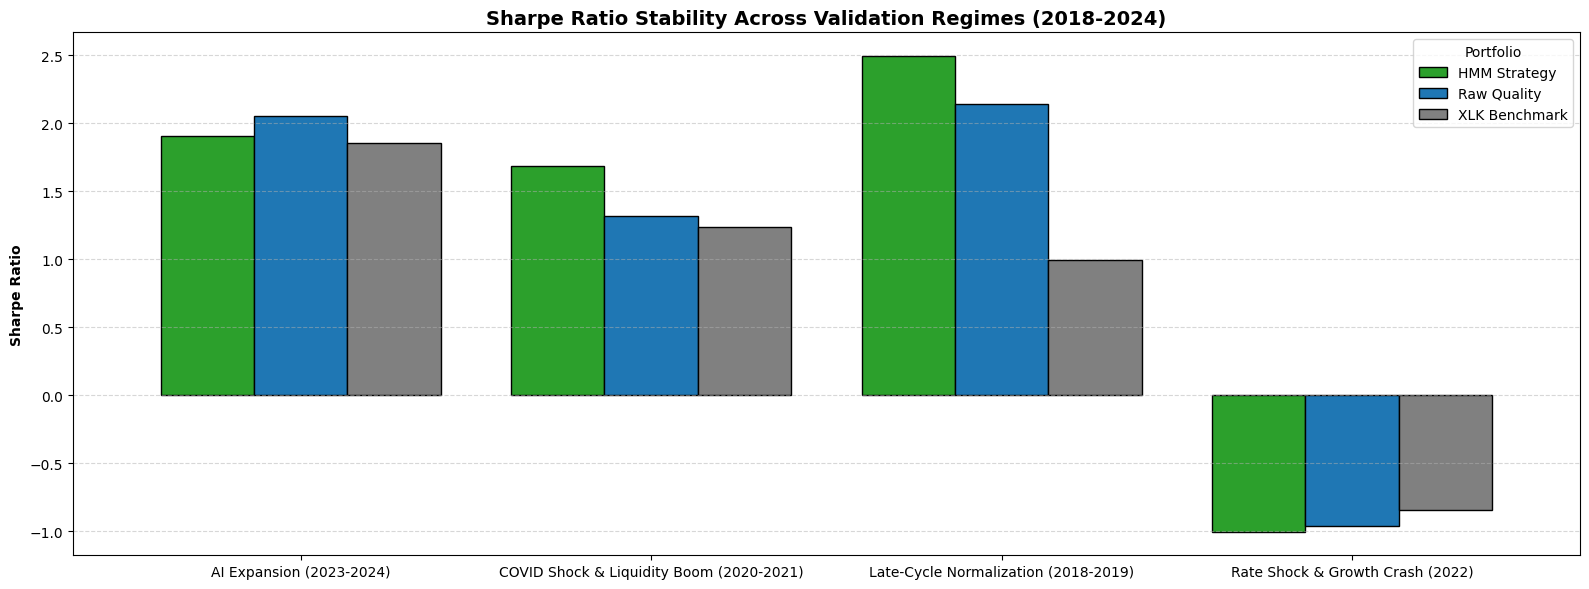

In [44]:
# Historical sub-periods (Regimes)
periods = {
    'Late-Cycle Normalization (2018-2019)': ('2018-01-01', '2019-12-31'),
    'COVID Shock & Liquidity Boom (2020-2021)': ('2020-01-01', '2021-12-31'),
    'Rate Shock & Growth Crash (2022)': ('2022-01-01', '2022-12-31'),
    'AI Expansion (2023-2024)': ('2023-01-01', '2024-12-31')}

def get_period_stats(returns_series, start, end):
    sliced = returns_series.loc[start:end]
    if len(sliced) < 20:
        return [np.nan, np.nan, np.nan, np.nan]

    ann_ret = (1 + sliced).prod() ** (252 / len(sliced)) - 1
    ann_vol = sliced.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    cum = (1 + sliced).cumprod()
    dd = (cum / cum.cummax()) - 1
    max_dd = dd.min()

    return [ann_ret, ann_vol, sharpe, max_dd]

metrics = ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max Drawdown']
regime_results = {}

# Portfolios
for period_name, (start, end) in periods.items():
    validation_index = validation_res.index

    actual_start = validation_index[validation_index >= start][0] \
        if len(validation_index[validation_index >= start]) > 0 else validation_index[0]

    actual_end = validation_index[validation_index <= end][-1] \
        if len(validation_index[validation_index <= end]) > 0 else validation_index[-1]

    strat_stats = get_period_stats(validation_res['HMM Top 30% Strategy'], actual_start, actual_end)
    raw_stats = get_period_stats(validation_res['Raw Top 30% Strategy'], actual_start, actual_end)
    bench_stats = get_period_stats(validation_res['XLK Benchmark'], actual_start, actual_end)

    regime_results[(period_name, 'HMM Strategy')] = strat_stats
    regime_results[(period_name, 'Raw Quality')] = raw_stats
    regime_results[(period_name, 'XLK Benchmark')] = bench_stats

df_temporal = pd.DataFrame(regime_results, index=metrics).T


print("TEMPORAL ROBUSTNESS: REGIME-BY-REGIME BREAKDOWN")
pd.set_option('display.max_rows', 50)
display(df_temporal.round(4))
pd.reset_option('display.max_rows')

# Sharpe ratios for plotting
sharpes = df_temporal['Sharpe'].unstack()

fig, ax = plt.subplots(figsize=(16, 6))
sharpes.plot(kind='bar', ax=ax, width=0.8, color=['#2ca02c', '#1f77b4', 'gray'], edgecolor='black')

plt.title('Sharpe Ratio Stability Across Validation Regimes (2018-2024)', fontweight='bold', fontsize=14)
plt.ylabel('Sharpe Ratio', fontweight='bold')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Portfolio', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Late-Cycle Normalization (2018–2019)**: Raw Quality delivered the highest absolute return (54.9%), while the HMM overlay achieved the strongest volatility-adjusted return (2.49). The XLK benchmark did not even have the chance to compete.

**COVID Shock & Liquidity Boom (2020–2021)**
The HMM strategy produced the highest Sharpe (1.69) with much lower volatility than Raw Quality. The HMM strategy benefits from high stress recovery environments in performance competition against benchmarks.

**Rate Shock & Growth Crash (2022)**
All portfolios generated negative returns during the growth selloff.
The HMM overlay limited losses most effectively, reducing drawdown to -14.1% versus -42.3% (3x) for Raw Quality and -33.1% for XLK.

**AI Expansion (2023–2024)**
The HMM strategy delivered slightly lower returns than the Raw strategy (53.9%) but maintained competitive risk-adjusted performance with lower drawdown.


## Regime Transition Diagnostics (HMM)

In [45]:
validation_data = test_data.loc[test_start:test_end]
validation_scaled = test_scaled.loc[test_start:test_end]

state_series = pd.Series(model.predict(validation_scaled),
                         index=validation_data.index,
                         name='State')


if high_risk_state == 0:
    state_labels = {0: 'High Risk', 1: 'Low Risk'}
else:
    state_labels = {1: 'High Risk', 0: 'Low Risk'}

state_named = state_series.map(state_labels)

# Transition Matrix
trans_mat = pd.DataFrame(
    model.transmat_,
    index=[state_labels[i] for i in range(model.n_components)],
    columns=[state_labels[i] for i in range(model.n_components)])

# Expected Regime Duration
validation_days = len(state_series)

expected_duration = pd.DataFrame({
    'Expected Duration (Days)': {
        state_labels[i]: 1 / (1 - model.transmat_[i, i])
        for i in range(model.n_components)}})

expected_duration['% of Validation Sample'] = (
    expected_duration['Expected Duration (Days)'] / validation_days * 100)

# Realized Regime Duration
runs = (state_series != state_series.shift()).cumsum()
spell_lengths = state_series.groupby(runs).agg(['first', 'size'])
realized_duration = spell_lengths.groupby('first')['size'].mean()
realized_duration.index = realized_duration.index.map(state_labels)
realized_duration.name = 'Realized Avg Duration (Days)'


# Pre-Drawdown Regime Frequency
validation_cum = (1 + validation_res['HMM Top 30% Strategy']).cumprod()
rolling_max = validation_cum.cummax()
drawdown = validation_cum / rolling_max - 1
stress_dates = drawdown[drawdown < -0.05].index
pre_dd_states = state_named.shift(5).loc[stress_dates]
pre_dd_freq = pre_dd_states.value_counts(normalize=True) * 100


print("REGIME TRANSITION DIAGNOSTICS APPENDIX (VALIDATION ONLY)")


print("\n1. TRANSITION PROBABILITY MATRIX")
print("Probability of remaining in or switching between latent regimes.\n")
display(trans_mat.round(4))


print("\n" + "="*85)
print("2. EXPECTED REGIME PERSISTENCE")
print(f"Theoretical expected duration implied by transition probabilities (out of {validation_days} validation trading days).\n")
display(expected_duration.round(2))


print("\n" + "="*85)
print("3. REALIZED REGIME DURATION")
print("Observed average persistence across validation data.\n")
display(realized_duration.round(2))


print("\n" + "="*85)
print("4. PRE-DRAWDOWN REGIME FREQUENCY")
print("Regime composition five trading days before drawdowns exceeding 5%.\n")
display(pre_dd_freq.round(2))

REGIME TRANSITION DIAGNOSTICS APPENDIX (VALIDATION ONLY)

1. TRANSITION PROBABILITY MATRIX
Probability of remaining in or switching between latent regimes.



,Low Risk,High Risk
Low Risk,0.9937,0.0063
High Risk,0.0123,0.9877



2. EXPECTED REGIME PERSISTENCE
Theoretical expected duration implied by transition probabilities (out of 1761 validation trading days).



,Expected Duration (Days),% of Validation Sample
Low Risk,158.07,8.98
High Risk,81.13,4.61



3. REALIZED REGIME DURATION
Observed average persistence across validation data.



,Realized Avg Duration (Days)
first,
Low Risk,62.86
High Risk,67.77



4. PRE-DRAWDOWN REGIME FREQUENCY
Regime composition five trading days before drawdowns exceeding 5%.



,proportion
State,
High Risk,75.0
Low Risk,25.0


**Transition Matrix:**  
There is a stable regime identification with the model remaining in the same latent state over 98% of the time with almost no short-term state switching.

**Regime Persistence:**  
 Low-risk predonimates (158 trading days) over the high-risk regime (81 trading days) risk-off environments are shorter-lived but characterized by higher expansions.

**Realized Duration:**  
Observed regime durations are shorter than theoretical expectations but remain economically meaningful, confirming that regime segmentation is sustained over multi-month windows rather than transient noise.

# **4. Final Unseen Holdout**

The final holdout period evaluates strategy performance on completely unseen data (**2025-01-01** – **2026-03-31**) not used during model development, parameter selection, or validation testing.

This serves as evidence against overfitting to historical validation regimes.

## Monthly Portfolio Allocations (2025–2026)

In [46]:
holdings_holdout = target_alloc.loc[holdout_start:holdout_end].resample('M').last()

monthly_comp_holdout = []

for date, row in holdings_holdout.iterrows():
    active = row[row > 0].sort_values(ascending=False)

    month_data = {'Month': date.strftime('%b-%Y')}

    for i, (stock, weight) in enumerate(active.items(), 1):
        month_data[f'Holding {i}'] = f'{stock} ({weight:.0%})'

    monthly_comp_holdout.append(month_data)

monthly_comp_holdout_df = pd.DataFrame(monthly_comp_holdout)

display(monthly_comp_holdout_df)

,Month,Holding 1,Holding 2,Holding 3
0,Jan-2025,QCOM (10%),AMD (10%),ADBE (10%)
1,Feb-2025,QCOM (10%),AMD (10%),ADBE (10%)
2,Mar-2025,QCOM (10%),AMD (10%),ADBE (10%)
3,Apr-2025,QCOM (10%),AMD (10%),ADBE (10%)
4,May-2025,AMD (33%),ADBE (33%),INTU (33%)
5,Jun-2025,ADBE (33%),INTU (33%),CSCO (33%)
6,Jul-2025,INTU (33%),CSCO (33%),AMAT (33%)
7,Aug-2025,INTC (33%),AMD (33%),INTU (33%)
8,Sep-2025,INTC (33%),AMD (33%),AMAT (33%)
9,Oct-2025,INTC (10%),AMD (10%),AMAT (10%)


Selected quality leaders align with current market trends.

## Cumulative Performance

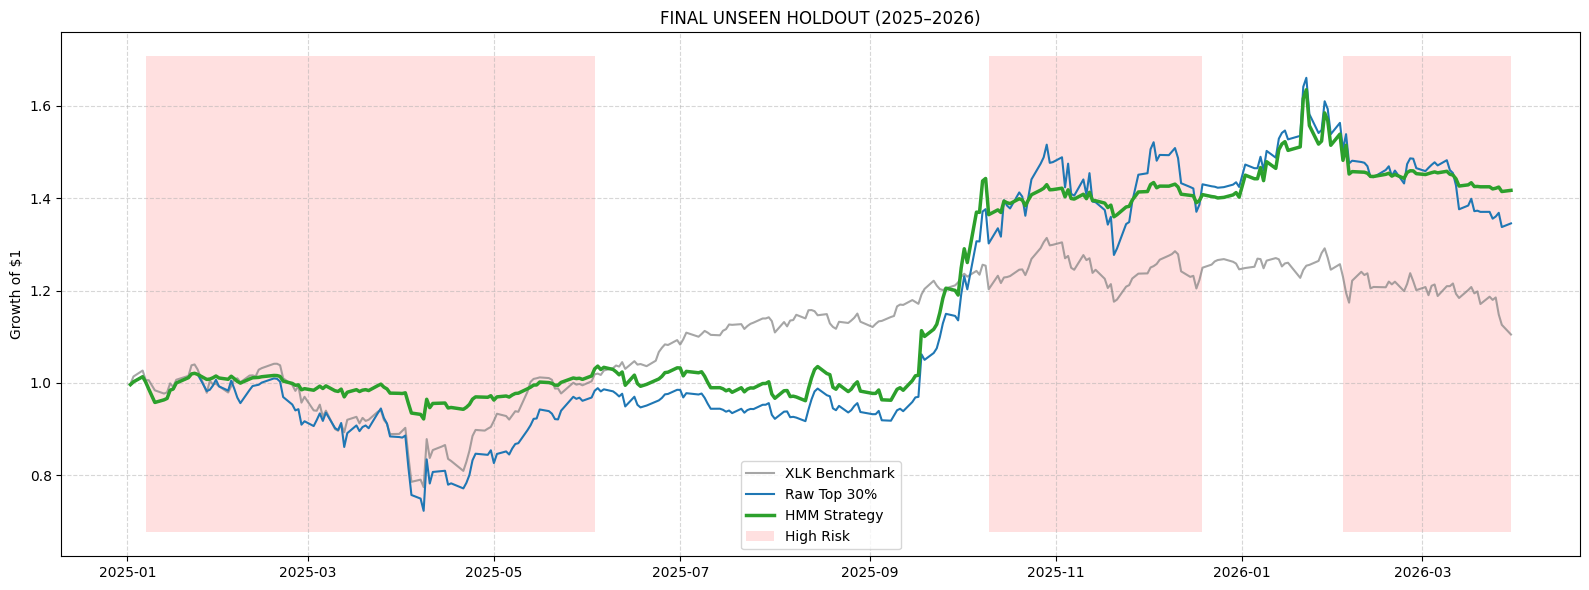

In [47]:
hold_strat=holdout_res['HMM Top 30% Strategy']
hold_raw=holdout_res['Raw Top 30% Strategy']
hold_bench=holdout_res['XLK Benchmark']
hold_regime=prob_high_risk_oos.loc[holdout_start:holdout_end]>0.5

cum_hold_strat=(1+hold_strat).cumprod(); cum_hold_raw=(1+hold_raw).cumprod(); cum_hold_bench=(1+hold_bench).cumprod()

fig,ax=plt.subplots(figsize=(16,6))
ax.plot(cum_hold_bench.index,cum_hold_bench,color='gray',label='XLK Benchmark',alpha=0.7)
ax.plot(cum_hold_raw.index,cum_hold_raw,color='#1f77b4',label='Raw Top 30%')
ax.plot(cum_hold_strat.index,cum_hold_strat,color='#2ca02c',linewidth=2.5,label='HMM Strategy')
ax.fill_between(hold_regime.index,ax.get_ylim()[0],ax.get_ylim()[1],where=hold_regime,facecolor='red',alpha=0.12,label='High Risk')
ax.set_title('FINAL UNSEEN HOLDOUT (2025–2026)'); ax.set_ylabel('Growth of $1'); ax.legend(); ax.grid(True,linestyle='--',alpha=0.5)
plt.tight_layout(); plt.show()

- The strategy remains competitive on fully unseen data.
- The HMM strategy delivers smoother performance and finishes above the XLK benchmark.
- During the April 4-9 2025 tariff-driven selloff, the regime overlay limited drawdown to approximately **-13%**, compared with **-25.7%** (-2x) for XLK and **-29%** for the raw strategy.


## Drawdown Chart

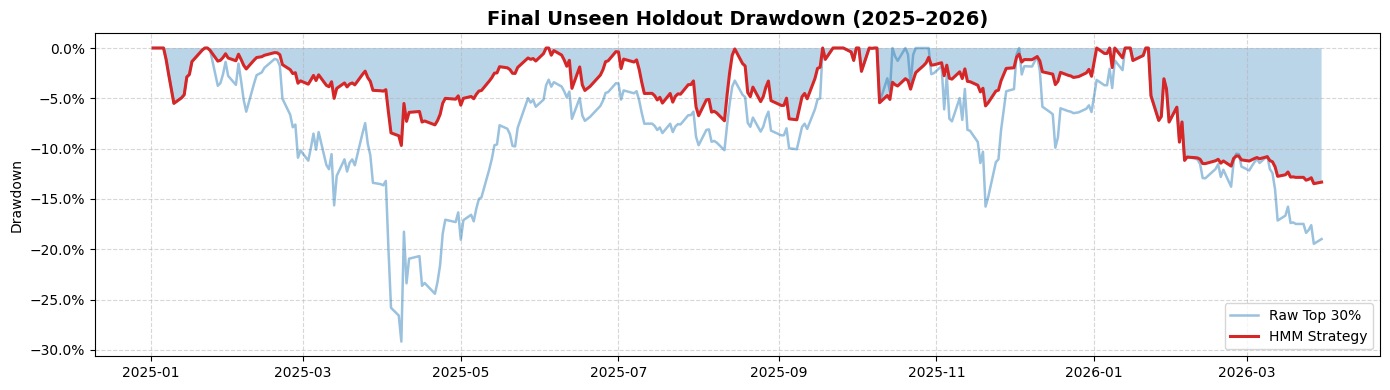

In [48]:
fig3, ax3 = plt.subplots(figsize=(14,4))

hold_dd_strat = (cum_hold_strat / cum_hold_strat.cummax()) - 1
hold_dd_raw = (cum_hold_raw / cum_hold_raw.cummax()) - 1

ax3.plot(hold_dd_raw.index, hold_dd_raw, color='#1f77b4', alpha=0.45, linewidth=1.8, label='Raw Top 30%')
ax3.plot(hold_dd_strat.index, hold_dd_strat, color='#d62728', linewidth=2.2, label='HMM Strategy')
ax3.fill_between(hold_dd_strat.index, hold_dd_strat, 0, alpha=0.30)

ax3.set_title('Final Unseen Holdout Drawdown (2025–2026)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Drawdown')
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax3.legend(loc='lower right')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Monthly Heatmap

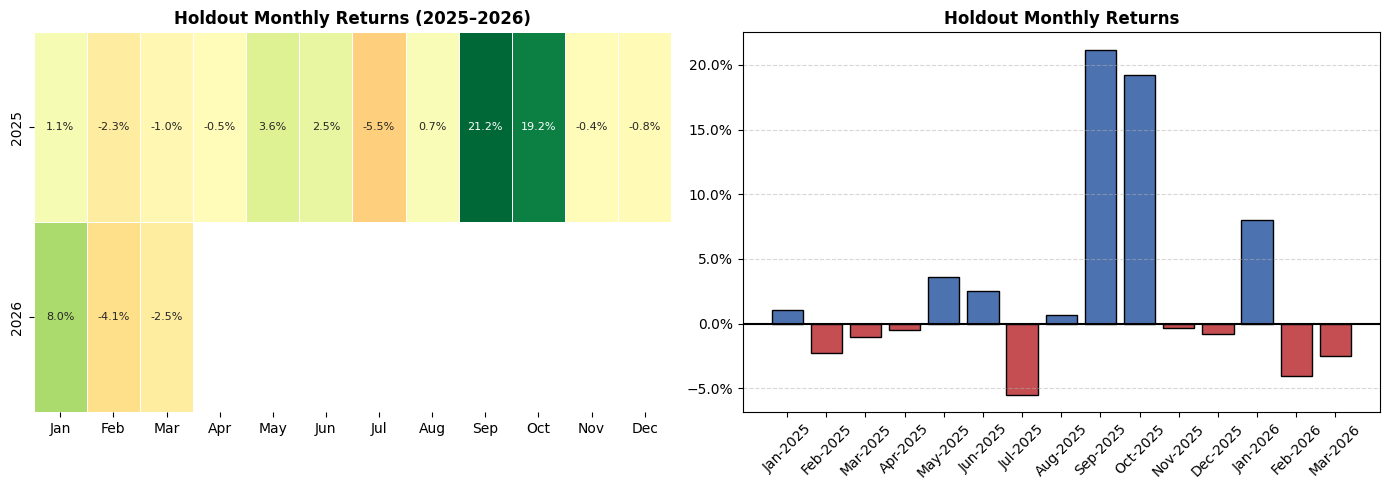

In [49]:
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14,5), gridspec_kw={'width_ratios':[1,1]})

hold_monthly = holdout_res['HMM Top 30% Strategy'].resample('ME').apply(lambda x:(1+x).prod()-1)
hold_df = pd.DataFrame({'Return': hold_monthly})
hold_df['Year'] = hold_df.index.year
hold_df['Month'] = hold_df.index.month
hold_pivot = hold_df.pivot(index='Year', columns='Month', values='Return')
hold_pivot.columns = [calendar.month_abbr[i] for i in hold_pivot.columns]

sns.heatmap(hold_pivot, annot=True, fmt=".1%", cmap="RdYlGn", center=0, cbar=False,
            annot_kws={"size":8}, ax=ax3, linewidths=.5)

ax3.set_title('Holdout Monthly Returns (2025–2026)', fontweight='bold')
ax3.set_ylabel('')
ax3.set_xlabel('')

hold_monthly_bar = holdout_res['HMM Top 30% Strategy'].resample('ME').apply(lambda x:(1+x).prod()-1)
hold_labels = hold_monthly_bar.index.strftime('%b-%Y')
hold_colors = ['#4c72b0' if v > 0 else '#c44e52' for v in hold_monthly_bar]

ax4.bar(hold_labels, hold_monthly_bar, color=hold_colors, edgecolor='black')
ax4.axhline(0, color='black')
ax4.set_title('Holdout Monthly Returns', fontweight='bold')
ax4.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- The strategy did not perform evenly across the year, with weakness concentrated during **Q1–Q2 2025**, followed by strong recovery in **September (+21.2%)** and **October (+19.2%)**.

- The strategy adapts effectively after stressed periods, capturing recoveries properly

## **Final holdout stats**

In [50]:
holdout_perf = pd.DataFrame(
    {col: get_stats(holdout_res[col]) for col in holdout_res.columns},
    index=['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max Drawdown', 'Win Rate']).T

print("\nFINAL UNSEEN HOLDOUT (2025–2026)")
display(holdout_perf.round(4))


FINAL UNSEEN HOLDOUT (2025–2026)


,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Win Rate
HMM Top 30% Strategy,0.3277,0.2355,1.3911,-0.1348,0.5452
Raw Top 30% Strategy,0.2729,0.3694,0.7389,-0.2918,0.5452
Bottom 30% Strategy,-0.0928,0.3153,-0.2944,-0.3127,0.5000
Universe EW (No Alpha),0.1570,0.2721,0.5769,-0.2401,0.5452
XLK Benchmark,0.0845,0.2688,0.3142,-0.2566,0.5903


The final unseen holdout confirms that the strategy works not only in the validation sample. The HMM Top 30% strategy delivered the strongest risk-adjusted performance with **32.8% annualized return**, **Sharpe 1.39**, and a maximum drawdown of only **-13.5%**.

While the raw factor strategy generated similar directional returns  , its drawdown expanded to **-29.2%** and volatility rose to **36.9%**, showing showing the lack of HMM component

The Bottom 30% portfolio produced **negative annualized returns (-9.3%)**, confirming that the quality ranking framework distinguished strong from weak names even in unseen data.

## Portfolio Attribution & Allocation Diagnostics

### Holdout 2025–2026

In [51]:
print("FINAL HOLDOUT ATTRIBUTION (2025–2026)")
holdout_cum = (1 + holdout_res['HMM Top 30% Strategy']).cumprod()

print("\nFinal Portfolio Value:")
display(holdout_cum.tail().round(4))

holdout_alloc = (
    target_alloc.loc['2025-01-01':]
    .mean()
    .sort_values(ascending=False)
    .mul(100))

print("\nAverage Portfolio Weights (%)")
display(holdout_alloc.round(2).to_frame('Weight %'))

FINAL HOLDOUT ATTRIBUTION (2025–2026)

Final Portfolio Value:


,HMM Top 30% Strategy
Date,
2026-03-24,1.4203
2026-03-25,1.4217
2026-03-26,1.4243
2026-03-27,1.4147
2026-03-30,1.4172



Average Portfolio Weights (%)


,Weight %
AMD,14.60
ADBE,11.06
INTC,9.75
INTU,7.82
CSCO,6.94
AMAT,5.56
QCOM,3.73
AAPL,1.70
NVDA,0.00
MSFT,0.00


- The TOP 3 seats in the holdout allocation are taken by  **AMD (14.6%)**, **ADBE (11.1%)**, and **INTC (9.8%)**

- **NVDA and MSFT received zero average allocation** and APPL minimal (1.7%). With that said the model does not simply chase large-cap momentum or rely on benchmark-heavy “winner” stocks.
  

### Structural Allocation Bias Analysis 2018–2026

In [52]:
print("STRUCTURAL ALLOCATION BIAS ANALYSIS (2018–2026)")
full_oos_alloc = (
    target_alloc.loc['2018-01-01':]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
)

print("\nAverage Portfolio Weights Across Full OOS (%)")
display(full_oos_alloc.round(2).to_frame('Weight %'))

STRUCTURAL ALLOCATION BIAS ANALYSIS (2018–2026)

Average Portfolio Weights Across Full OOS (%)


,Weight %
NVDA,10.29
CSCO,9.43
ADBE,7.75
INTU,6.35
AMD,6.18
AAPL,5.89
QCOM,5.68
INTC,5.36
MSFT,4.77
AMAT,3.46


# **5. Statistical Significance Analysis**

This section assesses whether observed performance gains are statistically significant rather than noise and randomness.

## Return Significance Analysis

In [53]:
def annualized_sharpe(r):
    return np.sqrt(252) * r.mean() / r.std()

def sharpe_difference_test(s1, s2):
    s1, s2 = s1.align(s2, join='inner')
    n = len(s1)

    sr1, sr2 = annualized_sharpe(s1), annualized_sharpe(s2)
    rho = np.corrcoef(s1, s2)[0, 1]

    denom = np.sqrt((1 - rho + 0.5*(sr1**2 + sr2**2 - 2*rho*sr1*sr2)) / (n - 1))
    z_stat = (sr1 - sr2) / denom
    p_val = 2 * (1 - norm.cdf(abs(z_stat)))

    return pd.Series({
                      'HMM Top 30% Strategy': sr1,
                      'Raw Top 30% Strategy': sr2,
                      'Sharpe Improvement': sr1 - sr2,
                      'Z-stat': z_stat,
                      'P-value': p_val})

def bootstrap_alpha(strategy, benchmark, n_boot=5000):
    strategy, benchmark = strategy.align(benchmark, join='inner')
    excess = strategy - benchmark

    boot = [(excess.sample(frac=1, replace=True).mean()*252) for _ in range(n_boot)]

    return pd.Series({'Mean Annual Alpha': np.mean(boot),
                      'CI Lower (2.5%)': np.percentile(boot, 2.5),
                      'CI Upper (97.5%)': np.percentile(boot, 97.5)})

def excess_return_ttest(strategy, benchmark):
    strategy, benchmark = strategy.align(benchmark, join='inner')
    excess = strategy - benchmark
    t_stat, p_val = ttest_1samp(excess, 0)

    return pd.Series({'Mean Daily Excess': excess.mean(),
                      'T-statistic': t_stat,
                      'P-value': p_val})

def sig_label(p):
    return "*** Highly Significant" if p < 0.01 else \
           "** Significant" if p < 0.05 else \
           "* Weak Significance" if p < 0.10 else \
           "Not Significant"

# Validation

val_sharpe = sharpe_difference_test(validation_res['HMM Top 30% Strategy'], validation_res['Raw Top 30% Strategy'])
val_alpha  = bootstrap_alpha(validation_res['HMM Top 30% Strategy'], validation_res['XLK Benchmark'])
val_ttest  = excess_return_ttest(validation_res['HMM Top 30% Strategy'], validation_res['XLK Benchmark'])

# Holdout

hold_sharpe = sharpe_difference_test(holdout_res['HMM Top 30% Strategy'], holdout_res['Raw Top 30% Strategy'])
hold_alpha  = bootstrap_alpha(holdout_res['HMM Top 30% Strategy'], holdout_res['XLK Benchmark'])
hold_ttest  = excess_return_ttest(holdout_res['HMM Top 30% Strategy'], holdout_res['XLK Benchmark'])


summary = pd.DataFrame({
    'Validation (2018–2024)': [val_sharpe['Sharpe Improvement'], val_sharpe['P-value'],
                               val_alpha['Mean Annual Alpha'], val_alpha['CI Lower (2.5%)'],
                               val_alpha['CI Upper (97.5%)'], val_ttest['T-statistic'],
                               val_ttest['P-value']],

    'Holdout (2025–2026)':    [hold_sharpe['Sharpe Improvement'], hold_sharpe['P-value'],
                               hold_alpha['Mean Annual Alpha'], hold_alpha['CI Lower (2.5%)'],
                               hold_alpha['CI Upper (97.5%)'], hold_ttest['T-statistic'],
                               hold_ttest['P-value']]
},
index=['Sharpe Improvement', 'Sharpe Test P-value', 'Bootstrap Mean Alpha',
       'Bootstrap CI Lower', 'Bootstrap CI Upper',
       'Excess Return T-stat', 'Excess Return P-value'])


print("RETURN SIGNIFICANCE ANALYSIS APPENDIX")

print("\n1. SHARPE DIFFERENCE TEST")
print("Tests whether the HMM overlay improves risk-adjusted returns relative to the raw factor strategy.")
print("A low p-value indicates the Sharpe improvement is statistically meaningful.\n")

print("VALIDATION")
display(val_sharpe.round(6))
print("Interpretation:", sig_label(val_sharpe['P-value']))

print("\nHOLDOUT")
display(hold_sharpe.round(6))
print("Interpretation:", sig_label(hold_sharpe['P-value']))


print("\n" + "="*85)
print("2. BOOTSTRAP ALPHA ESTIMATION")
print("Estimates annualized excess return versus XLK using resampling.")
print("If the confidence interval excludes zero, alpha is statistically robust.\n")

print("VALIDATION")
display(val_alpha.round(6))
print("Interpretation:",
      "Statistically Robust" if val_alpha['CI Lower (2.5%)'] > 0
      else "Positive but Not Statistically Confirmed")

print("\nHOLDOUT")
display(hold_alpha.round(6))
print("Interpretation:",
      "Statistically Robust" if hold_alpha['CI Lower (2.5%)'] > 0
      else "Positive but Not Statistically Confirmed")


print("\n" + "="*85)
print("3. EXCESS RETURN T-TEST")
print("Tests whether average daily excess return over XLK is statistically different from zero.")
print("Low p-values indicate consistent daily benchmark outperformance.\n")

print("VALIDATION")
display(val_ttest.round(6))
print("Interpretation:", sig_label(val_ttest['P-value']))

print("\nHOLDOUT")
display(hold_ttest.round(6))
print("Interpretation:", sig_label(hold_ttest['P-value']))


print("\n" + "="*85)
print("4. MASTER SUMMARY")
print("Consolidated statistical evidence across all return-based significance tests.\n")

display(summary.round(6))

RETURN SIGNIFICANCE ANALYSIS APPENDIX

1. SHARPE DIFFERENCE TEST
Tests whether the HMM overlay improves risk-adjusted returns relative to the raw factor strategy.
A low p-value indicates the Sharpe improvement is statistically meaningful.

VALIDATION


,0
HMM Top 30% Strategy,1.522281
Raw Top 30% Strategy,1.087662
Sharpe Improvement,0.434619
Z-stat,25.522363
P-value,0.000000


Interpretation: *** Highly Significant

HOLDOUT


,0
HMM Top 30% Strategy,1.319505
Raw Top 30% Strategy,0.835355
Sharpe Improvement,0.484150
Z-stat,13.012838
P-value,0.000000


Interpretation: *** Highly Significant

2. BOOTSTRAP ALPHA ESTIMATION
Estimates annualized excess return versus XLK using resampling.
If the confidence interval excludes zero, alpha is statistically robust.

VALIDATION


...

,0
Mean Daily Excess,0.000214
T-statistic,0.759936
P-value,0.447395


Interpretation: Not Significant

HOLDOUT


,0
Mean Daily Excess,0.000770
T-statistic,0.839618
P-value,0.401772


Interpretation: Not Significant

4. MASTER SUMMARY
Consolidated statistical evidence across all return-based significance tests.



,Validation (2018–2024),Holdout (2025–2026)
Sharpe Improvement,0.434619,0.484150
Sharpe Test P-value,0.000000,0.000000
Bootstrap Mean Alpha,0.054547,0.193102
Bootstrap CI Lower,-0.082988,-0.259290
Bootstrap CI Upper,0.197265,0.644195
Excess Return T-stat,0.759936,0.839618
Excess Return P-value,0.447395,0.401772


**Sharpe Difference Test:** The HMM overlay significantly improves risk-adjusted performance in both validation and holdout periods (p < 0.001),

**Bootstrap and Excess Return Tests:** Annual alpha is positive but not always statistically significant, and daily excess returns versus XLK are insignificant. Performance mainly originates from downside protection and compounding effects.

## Downside Protection Significance Analysis

In [54]:
from scipy.stats import ttest_rel, wilcoxon


def downside_protection_test(hmm_strategy, comparator):

    hmm_strategy, comparator = hmm_strategy.align(comparator, join='inner')
    stress_mask = comparator < 0

    hmm_down  = hmm_strategy[stress_mask]
    comp_down = comparator[stress_mask]
    diff = hmm_down - comp_down

    t_stat, p_t = ttest_rel(hmm_down, comp_down)
    w_stat, p_w = wilcoxon(diff)

    return pd.Series({
        'Avg Loss HMM (%)': hmm_down.mean()*100,
        'Avg Loss Comparator (%)': comp_down.mean()*100,
        'Protection Benefit (%)': diff.mean()*100,
        'Loss Reduction (%)': (1 - hmm_down.mean()/comp_down.mean())*100,
        'Paired t-stat': t_stat,
        'Paired t-value': p_t,
        'Wilcoxon p-value': p_w})

def protection_label(p):
    return "*** Highly Significant Protection" if p < 0.01 else \
           "** Significant Protection" if p < 0.05 else \
           "* Weak Protection Evidence" if p < 0.10 else \
           "Not Significant"

# Validation
val_vs_raw = downside_protection_test(validation_res['HMM Top 30% Strategy'], validation_res['Raw Top 30% Strategy'])
val_vs_xlk = downside_protection_test(validation_res['HMM Top 30% Strategy'], validation_res['XLK Benchmark'])

# Holdout
hold_vs_raw = downside_protection_test(holdout_res['HMM Top 30% Strategy'], holdout_res['Raw Top 30% Strategy'])
hold_vs_xlk = downside_protection_test(holdout_res['HMM Top 30% Strategy'], holdout_res['XLK Benchmark'])


downside_summary = pd.DataFrame({
    'Validation (2018–2024)': [val_vs_raw['Protection Benefit (%)'], val_vs_raw['Loss Reduction (%)'], val_vs_raw['Paired t-value']],
    'Validation vs XLK':      [val_vs_xlk['Protection Benefit (%)'], val_vs_xlk['Loss Reduction (%)'], val_vs_xlk['Paired t-value']],
    'Holdout (2025–2026)':    [hold_vs_raw['Protection Benefit (%)'], hold_vs_raw['Loss Reduction (%)'], hold_vs_raw['Paired t-value']],
    'Holdout vs XLK':         [hold_vs_xlk['Protection Benefit (%)'], hold_vs_xlk['Loss Reduction (%)'], hold_vs_xlk['Paired t-value']]
},
index=['Protection Benefit (%)', 'Loss Reduction (%)', 'Paired t-value'])


print("DOWNSIDE PROTECTION SIGNIFICANCE APPENDIX")

print("\n1. VALIDATION: HMM vs RAW")
print("Tests whether the HMM overlay reduces downside losses relative to the raw factor strategy.\n")

print("VALIDATION")
display(val_vs_raw.round(6))
print("Interpretation:", protection_label(val_vs_raw['Paired t-value']))


print("\n" + "="*85)
print("2. VALIDATION: HMM vs XLK")
print("Tests whether downside protection holds relative to the benchmark.\n")

print("VALIDATION")
display(val_vs_xlk.round(6))
print("Interpretation:", protection_label(val_vs_xlk['Paired t-value']))


print("\n" + "="*85)
print("3. HOLDOUT: HMM vs RAW")
print("Measures whether protection persists on unseen data.\n")

print("HOLDOUT")
display(hold_vs_raw.round(6))
print("Interpretation:", protection_label(hold_vs_raw['Paired t-value']))


print("\n" + "="*85)
print("4. HOLDOUT: HMM vs XLK")
print("Evaluates out-of-sample benchmark downside resilience.\n")

print("HOLDOUT")
display(hold_vs_xlk.round(6))
print("Interpretation:", protection_label(hold_vs_xlk['Paired t-value']))


print("\n" + "="*85)
print("5. MASTER SUMMARY")
print("Consolidated statistical evidence of capital preservation.\n")

display(downside_summary.round(6))

DOWNSIDE PROTECTION SIGNIFICANCE APPENDIX

1. VALIDATION: HMM vs RAW
Tests whether the HMM overlay reduces downside losses relative to the raw factor strategy.

VALIDATION


,0
Avg Loss HMM (%),-0.791072
Avg Loss Comparator (%),-1.445165
Protection Benefit (%),0.654093
Loss Reduction (%),45.260764
Paired t-stat,17.246409
Paired t-value,0.000000
Wilcoxon p-value,0.000000


Interpretation: *** Highly Significant Protection

2. VALIDATION: HMM vs XLK
Tests whether downside protection holds relative to the benchmark.

VALIDATION


,0
Avg Loss HMM (%),-0.666891
Avg Loss Comparator (%),-1.191867
Protection Benefit (%),0.524976
Loss Reduction (%),44.046527
Paired t-stat,13.910944
Paired t-value,0.000000
Wilcoxon p-value,0.000000


Interpretation: *** Highly Significant Protection

3. HOLDOUT: HMM vs RAW
Measures whether protection persists on unseen data.

HOLDOUT


,0
Avg Loss HMM (%),-0.845939
Avg Loss Comparator (%),-1.584109
Protection Benefit (%),0.738170
Loss Reduction (%),46.598450
Paired t-stat,7.812259
Paired t-value,0.000000
Wilcoxon p-value,0.000000


Interpretation: *** Highly Significant Protection

4. HOLDOUT: HMM vs XLK
Evaluates out-of-sample benchmark downside resilience.

HOLDOUT


,0
Avg Loss HMM (%),-0.542897
Avg Loss Comparator (%),-1.360413
Protection Benefit (%),0.817516
Loss Reduction (%),60.093235
Paired t-stat,6.960800
Paired t-value,0.000000
Wilcoxon p-value,0.000000


Interpretation: *** Highly Significant Protection

5. MASTER SUMMARY
Consolidated statistical evidence of capital preservation.



,Validation (2018–2024),Validation vs XLK,Holdout (2025–2026),Holdout vs XLK
Protection Benefit (%),0.654093,0.524976,0.73817,0.817516
Loss Reduction (%),45.260764,44.046527,46.59845,60.093235
Paired t-value,0.000000,0.000000,0.00000,0.000000


**Downside Protection Test:** In the validation and holdout horizons, the HMM strategy delivers statistically significant loss reductions (*p* < 0.001).

**Results:** Downside losses are reduced by **44–45% in validation** and **47–60% in the holdout period**.


# AI Usage Disclosure

**Level 4: – AI-Supported Task Completion (Coding)**
Gemini Pro was used in accordance with the permitted Level 4 guidelines to support the coding and implementation process. The tool assisted in generating and refining Python code for data preprocessing, feature engineering, Hidden Markov Model implementation, validation procedures, performance evaluation, and visualization. All AI-generated code was reviewed, tested, modified where necessary, and validated by the author prior to inclusion in the project. The analytical results, interpretations, and conclusions remain entirely the independent work of the author. All AI-generated contributions were critically evaluated and integrated by the author.
Comprehensive records of AI interactions, including prompts and outputs, were maintained as required.
- Example of Prompts used:
“Generate Python code for rolling z-score standardization.”
“Implement a two-state Gaussian Hidden Markov Model in Python based on the following parameters.”
“Create validation performance comparison tables.”
“Plot drawdown comparison between strategies.”

Tool used: Gemini Pro (Google)

Accessed at: https://gemini.google.com/

Date(s) of use: March – May 2026
